CNN PROJECT



Text Project

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D,Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [ ]:
texts = [
    "I Like the sports",
    "Basketball sports is good",
    "Absolutely nice experience",
    "Bad sports I dont want to play",
    "I dont like sports"
    ]
labels = [1,1,1,0,0]
labels = np.array(labels)
tokenizer = Tokenizer(num_words=1000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

max_length = 4
X = pad_sequences(sequences,maxlen=max_length, padding='post')
X = np.array(X)

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=1000, output_dim=50, input_length=max_length))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X, labels, epochs=14, batch_size=2, verbose=0)

In [ ]:
loss,accuracy = model.evaluate(X, labels, verbose=0)
print(f"Training Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

Training Loss: 0.4425, Accuracy: 1.0000


In [ ]:
sample_texts = ["I dont like player", "I like the sports is good and nice experience"]
sample_seq = tokenizer.texts_to_sequences(sample_texts)
sample_pad = pad_sequences(sample_seq, maxlen=max_length, padding='post')
predictions = model.predict(sample_pad)
def interpret_prediction(prob):
    if prob >= 0.5:
        return "Positive"
    else:
        return "Negative"
readable_preds =[interpret_prediction(p[0]) for p in predictions]
for i, text in enumerate(sample_texts):
    print(f"Text: '{text}'->Sentiment: {readable_preds[i]} (confidence: {predictions[i][0]*100:.1f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Text: 'I dont like player'->Sentiment: Negative (confidence: 42.8%)
Text: 'I like the sports is good and nice experience'->Sentiment: Positive (confidence: 58.0%)


Image Project

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

import kagglehub
import os

In [ ]:
path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Dataset path:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset path: /kaggle/input/cat-and-dog


In [ ]:
train_dir = os.path.join(path, "training_set", "training_set")
test_dir = os.path.join(path, "test_set", "test_set")

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_ds = tf.keras.utils.image_dataset_from_directory(train_dir,
image_size=IMG_SIZE,
batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
test_dir,
image_size=IMG_SIZE,
batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print(class_names)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.
['cats', 'dogs']


In [ ]:
normalization = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))


In [ ]:
base_model = MobileNetV2(weights = "imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

In [ ]:
model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, epochs=1, validation_data=val_ds)

251/251 ━━━━━━━━━━━━━━━━━━━━ 495s 2s/step - accuracy: 0.9719 - loss: 0.0702 - val_accuracy: 0.9862 - val_loss: 0.0408


In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:",acc)

ValueError: You must call `compile()` before using the model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


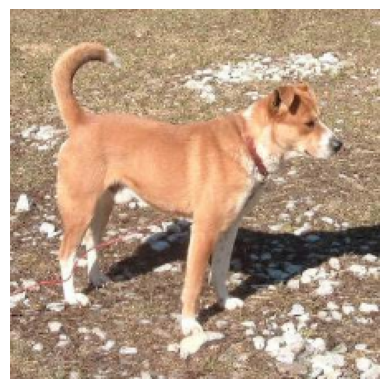

True Label: dogs
Predicted : dog
Confidence: 99.99838 %


In [ ]:
for images, labels in val_ds.take(1):
    img = images[2]
    true_label = labels[2]
    break
img_input = tf.expand_dims(img, axis=0)
prediction = model.predict(img_input)[0][0]
if prediction > 0.7:
    pred = "dog"
    conf = prediction * 100
else:
    pred = "cat"
    conf = (1 - prediction) * 100
true = class_names[int(true_label)]
plt.imshow(img)
plt.axis("off")
plt.show()

print("True Label:", true)
print("Predicted :", pred)
print("Confidence:", conf,"%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


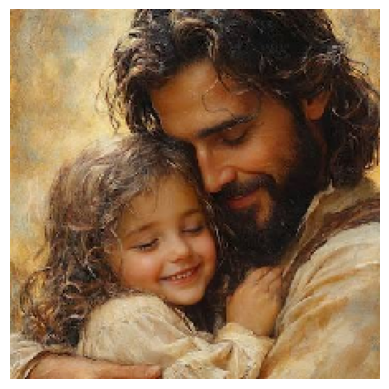

True Label: dogs
Predicted : god
Confidence: 91.46122 %


In [ ]:

img_sample ="god hug.jpg"
img = tf.keras.utils.load_img(img_sample, target_size=(224, 224))
img_input = tf.expand_dims(img, axis=0)
prediction = model.predict(img_input)[0][0]

if prediction > 0.9:
    pred = "god"
    conf = prediction * 100
else:
    pred = "cat"
    conf = (1 - prediction) * 100
true = class_names[int(true_label)]
plt.imshow(img)
plt.axis("off")
plt.show()

print("True Label:", true)
print("Predicted :", pred)
print("Confidence:", conf,"%")
